# Patterns In Youth Marijuana Use: Understanding Drug Usage in Minors through Decision Trees and Ensemble Methods

The following project is designed to determine which factors are most correlated with youth usage of marijuana, specifically with respect to demography (race, sex, household income, etc.) and parental influence (attitudes about drug use, level of involvement, etc.). To accomplish this, three separate approaches were taken using decision trees and ensemble methods to answer the following questions:

1) **Binary classification**: Which factors relate to whether a respondent has ever smoked marijuana or not?
2) **Multi-class classification**: Which factors relate to whether a respondent has smoked in the past year? (has not, has but not in the past year, has smoked in the past year)
3) **Regression**: Which factors relate to the age at which a respondent first used marijuana, if at all?

The data utilized for this project is sourced from the National Survey on Drug Use and Health, and contains a wide variety of responses to survey questions regarding the respondents' demographic backgrounds, usage/attitudes of drugs, and parental/peer influence. The data has previously been preprocessed to have all responses converted into a numerical format for the ease of analysis. Additionally, the dataset, which originally comprised upwards of 30,000 responses across 3,000 questions has been reduced to a more manageable size of around 10,000 responses and 79 total features (questions). This reduction also included filtering out all responses from those aged 18 and older.

Link to dataset:
https://www.samhsa.gov/data/data-we-collect/nsduh-national-survey-drug-use-and-health/datafiles/2023

## Import necessary libraries

In [1]:
# Installing scikit-learn
!pip install -Uqq scikit-learn

# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree, DecisionTreeRegressor
from sklearn.preprocessing import OneHotEncoder, LabelBinarizer
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import mean_squared_error, r2_score, classification_report, confusion_matrix as confusion_matrix_sklearn
from sklearn.inspection import PartialDependenceDisplay

## Generate DataFrame and Prepare Data for Model Analysis

In [2]:
df = pd.read_csv('C:/Users/jacob/Downloads/youth_data.csv') # load youth data and create pandas DataFrame
df.info() # inspect data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10561 entries, 0 to 10560
Data columns (total 79 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   IRALCFY      10561 non-null  int64  
 1   IRMJFY       10561 non-null  int64  
 2   IRCIGFM      10561 non-null  float64
 3   IRSMKLSS30N  10561 non-null  int64  
 4   IRALCFM      10561 non-null  float64
 5   IRMJFM       10561 non-null  float64
 6   IRCIGAGE     10561 non-null  int64  
 7   IRSMKLSSTRY  10561 non-null  int64  
 8   IRALCAGE     10561 non-null  int64  
 9   IRMJAGE      10561 non-null  int64  
 10  MRJFLAG      10561 non-null  int64  
 11  ALCFLAG      10561 non-null  int64  
 12  TOBFLAG      10561 non-null  int64  
 13  ALCYDAYS     10561 non-null  int64  
 14  MRJYDAYS     10561 non-null  int64  
 15  ALCMDAYS     10561 non-null  int64  
 16  MRJMDAYS     10561 non-null  int64  
 17  CIGMDAYS     10561 non-null  int64  
 18  SMKLSMDAYS   10561 non-null  int64  
 19  SCHF

The code below defines a list of 14 predictor variables of interest that could capture the influence demographics and parental influence have on marijuana usage. Specific considerations were made to exclude variables that could potentially exhibit multicollinearity with others (e.g. INCOME (household income) and POVERTY3 (household proximity to poverty level)). The target variables of interest are the following: has the respondent ever used marijuana (MRJFLAG), how frequently have they used marijuana in the past year (IRMJFY), and at what age did they first use marijuana (IRMJAGE). Each of these target variables will be reserved individually for modelling approach.

Prior to analysis, each variable is assessed for its values as well as for the presence of any null values, which will have to be corrected.

In [3]:
predictors = ['IRSEX', 'NEWRACE2', 'INCOME', 'COUTYP4', 'RLGATTD', 'EDUSCHGRD2', 'PRMJEVR2', 'PRVDRGO2', 'ARGUPAR', 'PARCHKHW', 'PARHLPHW', 'PRLMTTV2', 'PARLMTSN', 'PRPROUD2']

for predictor in predictors + ['MRJFLAG', 'IRMJFY', 'IRMJAGE']:
    print(f"\n{predictor}:")
    print(df[predictor].value_counts(dropna=False).sort_index())


IRSEX:
IRSEX
1    5387
2    5174
Name: count, dtype: int64

NEWRACE2:
NEWRACE2
1    4750
2    1284
3     368
4      50
5     503
6     795
7    2811
Name: count, dtype: int64

INCOME:
INCOME
1    1400
2    2766
3    1482
4    4913
Name: count, dtype: int64

COUTYP4:
COUTYP4
1    4897
2    4037
3    1627
Name: count, dtype: int64

RLGATTD:
RLGATTD
1.0    2081
2.0    8192
NaN     288
Name: count, dtype: int64

EDUSCHGRD2:
EDUSCHGRD2
1       26
2      451
3     1370
4     1589
5     1704
6     1673
7     1584
8      902
9       65
10       3
98     195
99     999
Name: count, dtype: int64

PRMJEVR2:
PRMJEVR2
1.0    8540
2.0    1920
NaN     101
Name: count, dtype: int64

PRVDRGO2:
PRVDRGO2
1.0     761
2.0    9698
NaN     102
Name: count, dtype: int64

ARGUPAR:
ARGUPAR
1.0    8359
2.0    2022
NaN     180
Name: count, dtype: int64

PARCHKHW:
PARCHKHW
1.0    8315
2.0    2169
NaN      77
Name: count, dtype: int64

PARHLPHW:
PARHLPHW
1.0    8151
2.0    2321
NaN      89
Name: count, dtype: int6

### Preparing Predictor Variables

Aside from the null values for many of the predictors, the variable EDUSCHGRD2 (representing current school grade) contains values of 98 and 99 which represent blank answers and skipped answers, respectively. As such, the code below replaces these values with null values that will later be removed entirely. Additionally, it should be noted that the values 1-10 represent grades 5 up to 2nd/3rd year of college, with the value of 1 representing all students in the 5th grade or below.

In [4]:
df['EDUSCHGRD2'] = df['EDUSCHGRD2'].replace([98, 99], np.nan)

All null values are then removed from the variables of interest.

In [5]:
df1 = df[predictors + ['MRJFLAG', 'IRMJFY', 'IRMJAGE']].dropna() # drop all null values for predictors and target variables

In [6]:
for predictor in predictors + ['MRJFLAG', 'IRMJFY', 'IRMJAGE']:
    print(f"\n{predictor}:")
    print(df1[predictor].value_counts(dropna=False).sort_index())


IRSEX:
IRSEX
1    4397
2    4343
Name: count, dtype: int64

NEWRACE2:
NEWRACE2
1    3911
2    1075
3     281
4      42
5     428
6     660
7    2343
Name: count, dtype: int64

INCOME:
INCOME
1    1160
2    2252
3    1206
4    4122
Name: count, dtype: int64

COUTYP4:
COUTYP4
1    4062
2    3360
3    1318
Name: count, dtype: int64

RLGATTD:
RLGATTD
1.0    1795
2.0    6945
Name: count, dtype: int64

EDUSCHGRD2:
EDUSCHGRD2
1.0       23
2.0      393
3.0     1217
4.0     1440
5.0     1607
6.0     1588
7.0     1534
8.0      871
9.0       64
10.0       3
Name: count, dtype: int64

PRMJEVR2:
PRMJEVR2
1.0    7136
2.0    1604
Name: count, dtype: int64

PRVDRGO2:
PRVDRGO2
1.0     673
2.0    8067
Name: count, dtype: int64

ARGUPAR:
ARGUPAR
1.0    7055
2.0    1685
Name: count, dtype: int64

PARCHKHW:
PARCHKHW
1.0    6953
2.0    1787
Name: count, dtype: int64

PARHLPHW:
PARHLPHW
1.0    6829
2.0    1911
Name: count, dtype: int64

PRLMTTV2:
PRLMTTV2
1.0    3052
2.0    5688
Name: count, dtype: int64

P

### Preparing Target Variables

Each target variable is then checked for the distribution of their values and adjusted in accordance with the requirements of each analysis.

In [7]:
df1['MRJFLAG'].value_counts() # examine class distribution for binary target variable

MRJFLAG
0    7444
1    1296
Name: count, dtype: int64

The target variable for binary classification is sufficiently a binary variable and ready for binary classification analysis.

The code below first assigns numerical labels for the three classes: 0 if the respondent has never used marijuana (represented as 991 in dataset), 1 if they have not used marijuana in the past year (993), and 2 if the respondent has used marijuana in the past year (values between 1-365 days).

In [8]:
df1['IRMJFY'].value_counts()

IRMJFY
991    7444
993     212
1        94
2        71
3        55
       ... 
86        1
184       1
112       1
336       1
340       1
Name: count, Length: 126, dtype: int64

In [9]:
df1['IRMJFY_classes'] = df1['IRMJFY'].map(lambda x: 0 if x == 991 else (1 if x == 993 else 2))

In [10]:
df1['IRMJFY_classes'].value_counts() # examine class distribution for multiclass target variable

IRMJFY_classes
0    7444
2    1084
1     212
Name: count, dtype: int64

The code below first generates a separate DataFrame to remove observations for respondents who have never used marijuana (represented by 991 values), before inspecting the distribution of ages of first use.

In [11]:
df1['IRMJAGE'].value_counts()

IRMJAGE
991    7444
14      317
15      291
13      241
16      173
12      140
17       45
11       42
10       16
9        12
8        10
7         7
6         2
Name: count, dtype: int64

In [12]:
# create DataFrame where respondents who have never used marijuana are removed
df3 = df1[df1['IRMJAGE'] != 991].copy()
df3['IRMJAGE'].value_counts()

IRMJAGE
14    317
15    291
13    241
16    173
12    140
17     45
11     42
10     16
9      12
8      10
7       7
6       2
Name: count, dtype: int64

### Exploratory Data Analysis

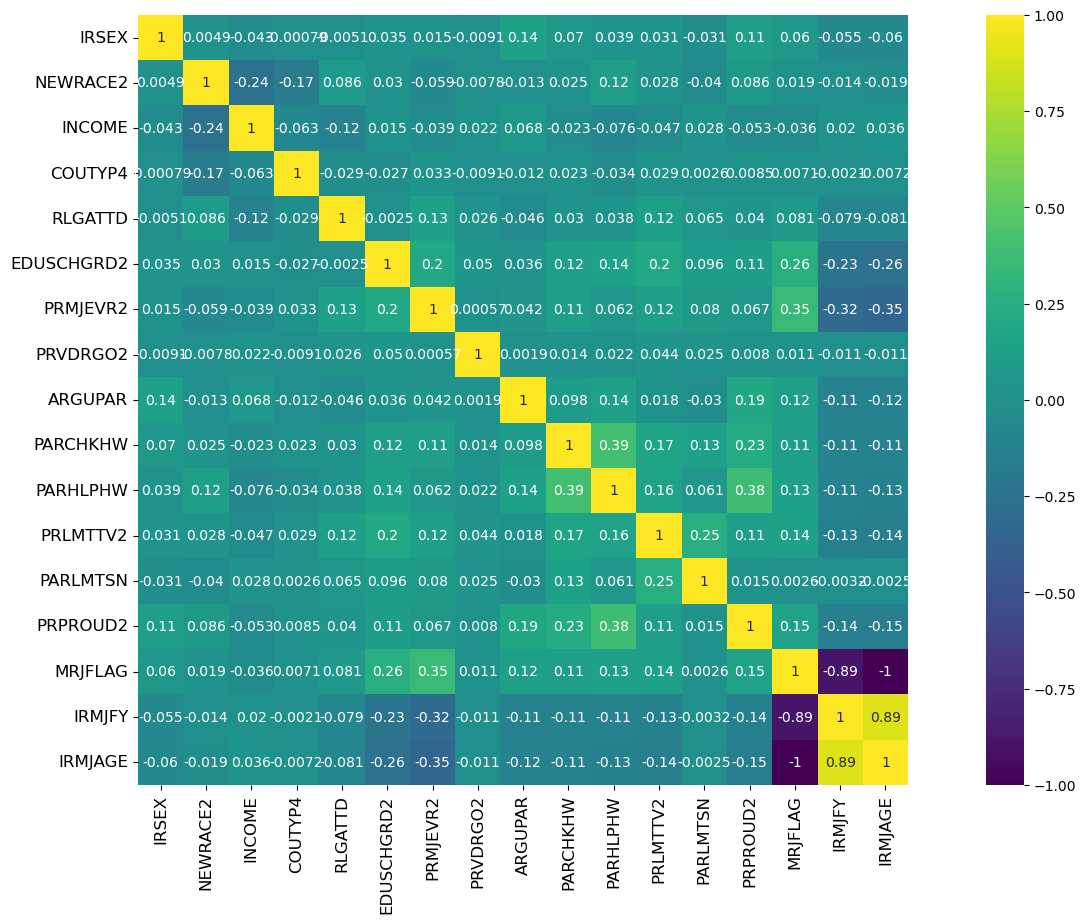

In [13]:
corr_matrix = df1[predictors + ['MRJFLAG', 'IRMJFY', 'IRMJAGE']].corr()

plt.figure(figsize=(20,10))

sns.heatmap(
    corr_matrix, vmax=1, vmin=-1, square=True, annot=True, cmap='viridis'
)

plt.tick_params(labelsize=12)

plt.show()

The correlation matrix conveys that the variable with the greatest correlation coefficients relative to the target variables of interest is PRMJEVR2, which was a survey question investigating parental attitudes around youth trying marijuana.  

The plot below examines the distribution of ages of respondents for when they first used marijuana.

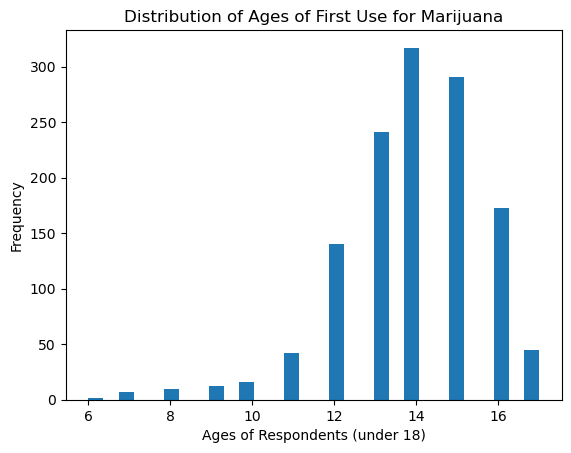

In [14]:
plt.hist(df3['IRMJAGE'], bins=30)
plt.title('Distribution of Ages of First Use for Marijuana')
plt.xlabel('Ages of Respondents (under 18)')
plt.ylabel('Frequency')
plt.show()

## Binary Classification: Has the respondent ever used marijuana?

In assessing the factors that are most relevant for whether a respondent has ever used marijuana, four separate models were applied. These included a standard decision tree model along with all three ensemble methods - bagging, random forest, and boosting. All four were applied for this formulation given the simplicity of two potential outcomes for the target variable, and to allow for the most direct comparison between all model types.

In [15]:
# define predictor variables and target variable
X = df1[predictors]
y = df1['MRJFLAG']

### Applying Decision Tree Model

The code below splits the dataset into training and test sets representing 80 and 20% of data points, respectively. A Decision Tree Classifer is then generated. Using cross-validation, the optimal hyperparameters are determined and used to generate a pruned decision tree model.

In [16]:
# split the data between test and train
X_train, X_test, y_train, y_test = train_test_split(X, y
                                                    , train_size=0.8
                                                    , random_state=1)

# fit decision tree model
tree_df1 = DecisionTreeClassifier(random_state=1)

In [17]:
# cross-validation to determine optimal hyperparameters
params = {'max_leaf_nodes': range(2,50),
          'min_samples_split': [2, 5, 10],
          'min_samples_leaf': [1, 2, 5]}

cv_df1 = GridSearchCV(tree_df1, params, cv=10)
cv_df1.fit(X_train, y_train)

# find best hyperparameters
print("Best hyperparameters:", cv_df1.best_params_)
print("Best CV score: {:.4f}".format(cv_df1.best_score_))

# define pruned decision tree model using best estimator from cross-validation object
prune_df1 = cv_df1.best_estimator_

Best hyperparameters: {'max_leaf_nodes': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV score: 0.8650


The visualization below conveys the cross-validation accuracy relative to the number of terminal leaf nodes for each size of the decision tree model. The optimal tree size is highlighted where the accuracy is highest.

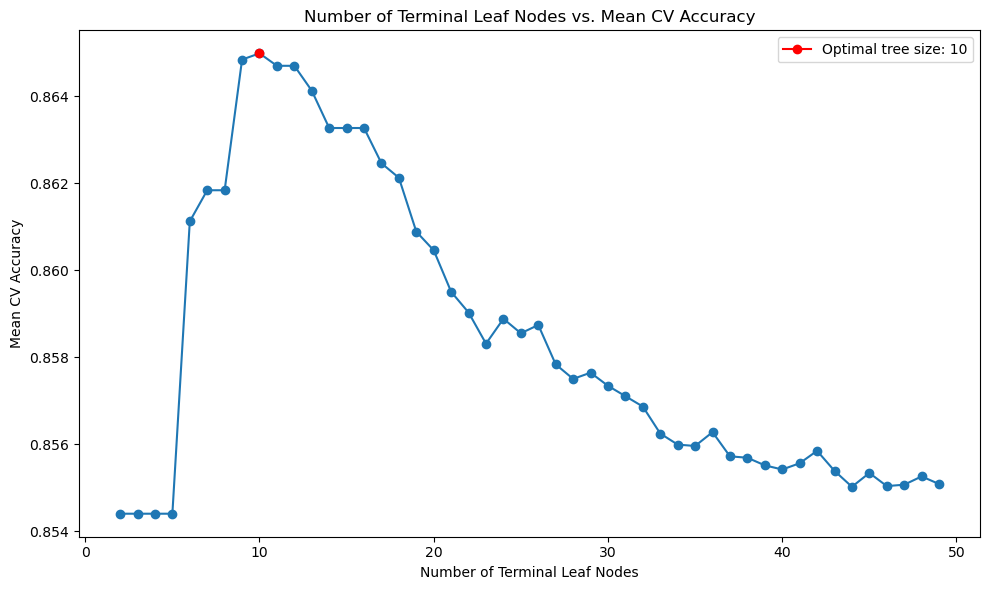

In [18]:
# define best_size and best CV score variables
best_size = cv_df1.best_params_['max_leaf_nodes']
best_score = cv_df1.best_score_

# plot number of terminal leaf nodes vs mean CV score for all combinations of hyperparameters
cv_results_df = pd.DataFrame(cv_df1.cv_results_)
leaf_node_scores = cv_results_df.groupby('param_max_leaf_nodes')['mean_test_score'].mean()

plt.figure(figsize=(10, 6))
plt.plot(leaf_node_scores.index, leaf_node_scores.values, 'o-')
plt.plot(best_size, best_score, 'ro-', label=f'Optimal tree size: {best_size}')
plt.xlabel('Number of Terminal Leaf Nodes')
plt.ylabel('Mean CV Accuracy')
plt.title('Number of Terminal Leaf Nodes vs. Mean CV Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

This pruned model is then plotted, applied to the test data, and assessed for its accuracy relative to the unpruned model.

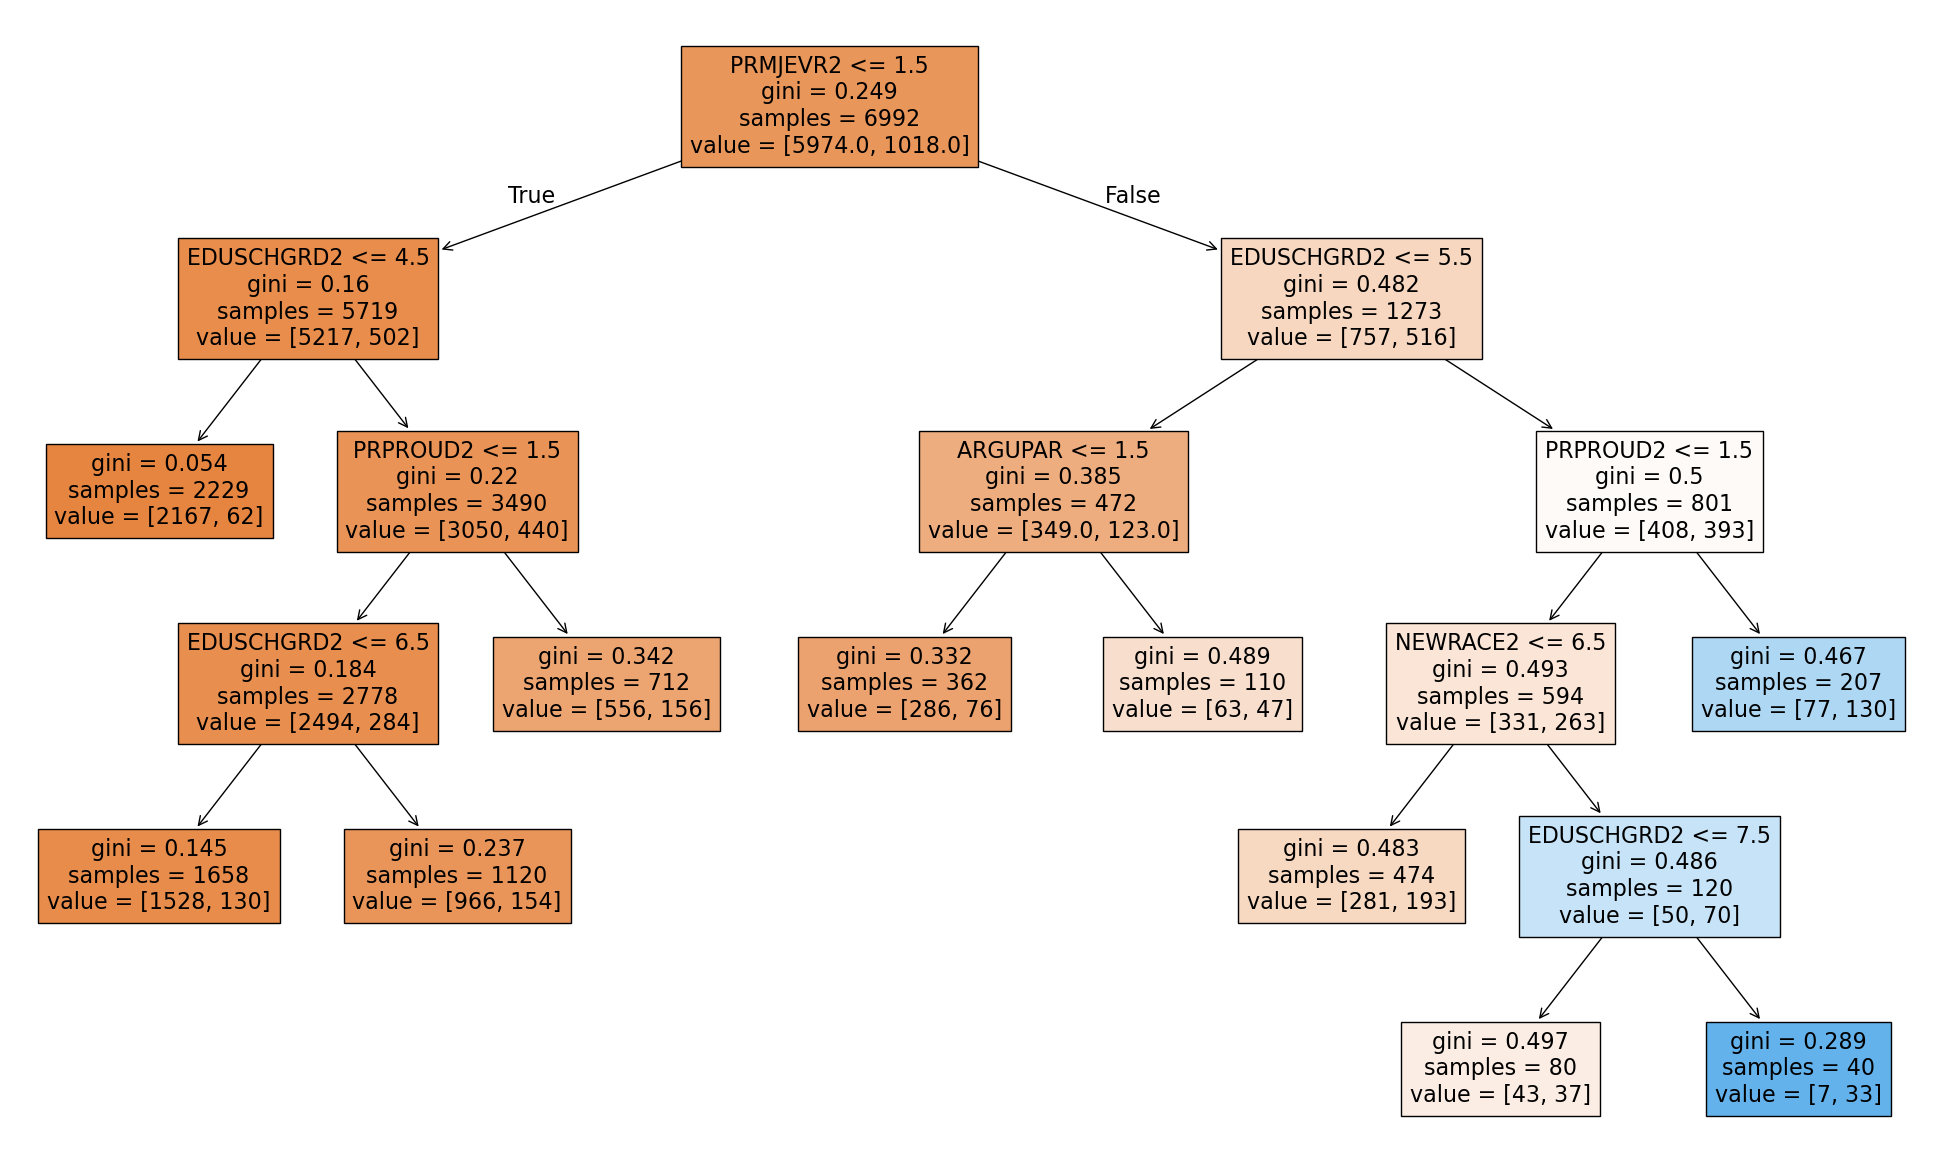

In [19]:
# plot pruned tree
plt.figure(figsize=(25, 15))
plt.title('Pruned Tree')
plot_tree(prune_df1, feature_names=X_train.columns, filled = True);

In [20]:
# predict on test data
pruned_tree_pred = prune_df1.predict(X_test)

# create confusion matrix
confusion_matrix_tree = pd.crosstab(index=pruned_tree_pred, columns=y_test, rownames=[''])
print(confusion_matrix_tree)

# calculate test accuracy and error rate
test_accuracy = prune_df1.score(X_test, y_test)
print("Accuracy: {:.2f}%".format(test_accuracy*100))
print("Error Rate: {:.2f}%".format((1 - test_accuracy)*100))

MRJFLAG     0    1
                  
0        1438  235
1          32   43
Accuracy: 84.73%
Error Rate: 15.27%


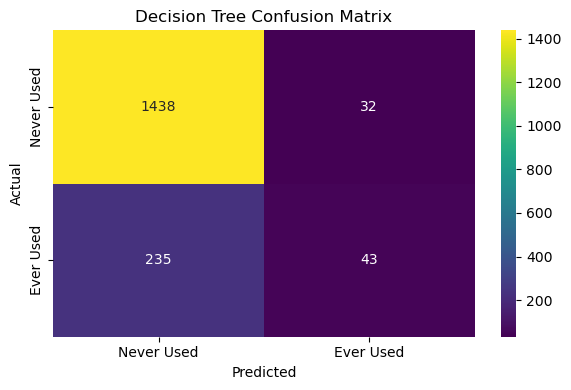

In [66]:
# generate confusion matrix using seaborn
cm_prune = confusion_matrix_sklearn(y_test, pruned_tree_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_prune, annot=True, fmt='d', xticklabels=['Never Used', 'Ever Used'], yticklabels=['Never Used', 'Ever Used'], cmap='viridis')
plt.title('Decision Tree Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [22]:
print(classification_report(y_test, pruned_tree_pred, target_names=['Never Used', 'Ever Used']))

              precision    recall  f1-score   support

  Never Used       0.86      0.98      0.92      1470
   Ever Used       0.57      0.15      0.24       278

    accuracy                           0.85      1748
   macro avg       0.72      0.57      0.58      1748
weighted avg       0.81      0.85      0.81      1748



This pruned model outperformed its unpruned counterpart with an accuracy of 84.73% compared to the unpruned model's accuracy of 79.12%. The pruned model is then assessed for the feature importances of each of the predictor variables.

In [23]:
importances = pd.DataFrame({'feature_name': X.columns, 'importance': prune_df1.feature_importances_})
importances = importances.sort_values('importance', ascending=False).reset_index(drop=True)
print(importances)

   feature_name  importance
0      PRMJEVR2    0.657684
1    EDUSCHGRD2    0.217265
2      PRPROUD2    0.081482
3       ARGUPAR    0.024957
4      NEWRACE2    0.018612
5         IRSEX    0.000000
6        INCOME    0.000000
7       COUTYP4    0.000000
8       RLGATTD    0.000000
9      PRVDRGO2    0.000000
10     PARCHKHW    0.000000
11     PARHLPHW    0.000000
12     PRLMTTV2    0.000000
13     PARLMTSN    0.000000


Compared to the unpruned model, which saw little disparity between its top features in terms of importance score, the pruned model was dominated by the PRMJEVR2 variable by a wide margin. This result is expected for a decision tree model whose greedy, top-down algorithm can tend to emphasize features that result in the greatest level of node purity upon splitting.

### Applying Bagging Model

A Random Forest Classifer is then applied to the same training data and inspected for the most important features as well as its training score. This bagging model is then used to generate predictions on the test data and examined for its accuracy, error rate, and F1 scores.

In [24]:
# fit Random Forests model
df1_bagging = RandomForestClassifier(random_state = 1)

Using cross-validation, the optimal hyperparameters are determined and used to generate an optimal bagging model.

In [25]:
# cross-validation to determine optimal hyperparameters
params_bag = {'n_estimators': [100, 300, 500],
              'max_features': [X_train.shape[1]], 
              'max_depth': [3, 5, 10, None],
              'min_samples_split': [2, 5, 10],
              'min_samples_leaf': [1, 2, 5]}

cv_bag = GridSearchCV(df1_bagging, params_bag, cv=5, n_jobs=-1)
cv_bag.fit(X_train, y_train)

# find best hyperparameters
print("Best hyperparameters:", cv_bag.best_params_)
print("Best CV score: {:.4f}".format(cv_bag.best_score_))

# define bagging model using best estimator from cross-validation object
df1_bagging = cv_bag.best_estimator_ 

Best hyperparameters: {'max_depth': 3, 'max_features': 14, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV score: 0.8647


In [26]:
# predict on test data
y_pred_bag = df1_bagging.predict(X_test)

# create confusion matrix
confusion_matrix_tree = pd.crosstab(index=y_pred_bag, columns=y_test, rownames=[''])
print(confusion_matrix_tree)

# calculate test accuracy and error rate
test_accuracy = df1_bagging.score(X_test, y_test)
print("Accuracy: {:.2f}%".format(test_accuracy*100))
print("Error Rate: {:.2f}%".format((1 - test_accuracy)*100))

MRJFLAG     0    1
                  
0        1443  237
1          27   41
Accuracy: 84.90%
Error Rate: 15.10%


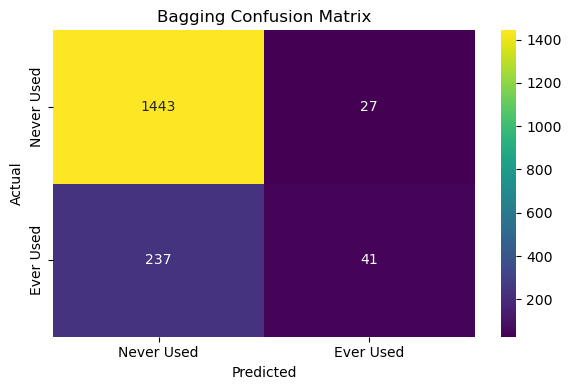

In [67]:
# generate confusion matrix using seaborn
cm_bag = confusion_matrix_sklearn(y_test, y_pred_bag)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_bag, annot=True, fmt='d', xticklabels=['Never Used', 'Ever Used'], yticklabels=['Never Used', 'Ever Used'], cmap='viridis')
plt.title('Bagging Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [28]:
print(classification_report(y_test, y_pred_bag, target_names=['Never Used', 'Ever Used']))

              precision    recall  f1-score   support

  Never Used       0.86      0.98      0.92      1470
   Ever Used       0.60      0.15      0.24       278

    accuracy                           0.85      1748
   macro avg       0.73      0.56      0.58      1748
weighted avg       0.82      0.85      0.81      1748



In [29]:
importances = pd.DataFrame({'feature_name': X.columns, 'importance': df1_bagging.feature_importances_})
importances = importances.sort_values('importance', ascending=False).reset_index(drop=True)
print(importances)

   feature_name  importance
0      PRMJEVR2    0.668335
1    EDUSCHGRD2    0.206157
2      PRPROUD2    0.062717
3       ARGUPAR    0.036502
4      NEWRACE2    0.006559
5      PRLMTTV2    0.006236
6      PARHLPHW    0.004455
7        INCOME    0.002934
8      PARCHKHW    0.002365
9       RLGATTD    0.001349
10     PARLMTSN    0.001330
11        IRSEX    0.001060
12      COUTYP4    0.000000
13     PRVDRGO2    0.000000


Based on the feature importance output, the top features for predicting marijuana usage include grade level (EDUSCHGRD2) and parental attitudes around youth using marijuana (PRMJEVR2). The optimal bagging model was slightly more accurate in its predictions compared to the optimal decision tree, however it correctly identified less respondents who had used marijuana. 

### Applying Random Forest Model

A Random Forest Classifer is again applied. Using cross-validation, the optimal hyperparameters are determined and used to generate an optimal random forest model, which is used to generate predictions on the test data and examined for its accuracy, error rate, and F1 scores.

In [30]:
# fit Random Forests model
df1_rf = RandomForestClassifier(random_state = 1)

In [31]:
# cross-validation to determine optimal hyperparameters
params_rf = {'n_estimators': [100, 300, 500],
              'max_features': ['sqrt', 0.5], 
              'max_depth': [3, 5, 10, None],
              'min_samples_split': [2, 5, 10],
              'min_samples_leaf': [1, 2, 5]}

cv_rf = GridSearchCV(df1_rf, params_rf, cv=5, n_jobs=-1)
cv_rf.fit(X_train, y_train)

# find best hyperparameters
print("Best hyperparameters:", cv_rf.best_params_)
print("Best CV score: {:.4f}".format(cv_rf.best_score_))

# define random forest model using best estimator from cross-validation object
df1_rf_final = cv_rf.best_estimator_ 

Best hyperparameters: {'max_depth': 5, 'max_features': 0.5, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}
Best CV score: 0.8643


In [32]:
# Predict values
y_pred_rf2 = df1_rf_final.predict(X_test)

# create confusion matrix
confusion_matrix_rf = pd.crosstab(index=y_pred_rf2, columns=y_test, rownames=[''])
print(confusion_matrix_rf)

# calculate test accuracy and error rate
test_accuracy_rf = df1_rf_final.score(X_test, y_test)
print("Accuracy: {:.2f}%".format(test_accuracy_rf*100))
print("Error Rate: {:.2f}%".format((1 - test_accuracy_rf)*100))

MRJFLAG     0    1
                  
0        1438  226
1          32   52
Accuracy: 85.24%
Error Rate: 14.76%


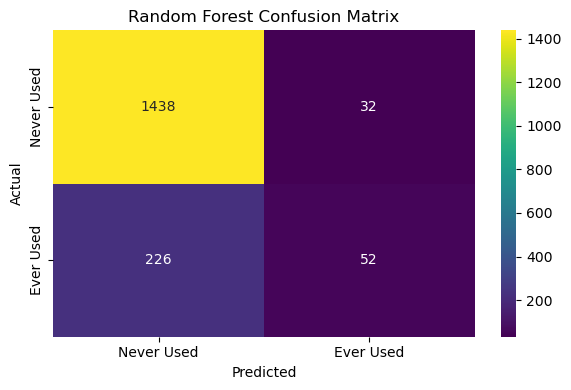

In [68]:
# generate confusion matrix using seaborn
cm_rf = confusion_matrix_sklearn(y_test, y_pred_rf2)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_rf, annot=True, fmt='d', xticklabels=['Never Used', 'Ever Used'], yticklabels=['Never Used', 'Ever Used'], cmap='viridis')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [34]:
print(classification_report(y_test, y_pred_rf2, target_names=['Never Used', 'Ever Used']))

              precision    recall  f1-score   support

  Never Used       0.86      0.98      0.92      1470
   Ever Used       0.62      0.19      0.29       278

    accuracy                           0.85      1748
   macro avg       0.74      0.58      0.60      1748
weighted avg       0.83      0.85      0.82      1748



In [35]:
importances = pd.DataFrame({'feature_name': X.columns, 'importance': df1_rf_final.feature_importances_})
importances = importances.sort_values('importance', ascending=False).reset_index(drop=True)
print(importances)

   feature_name  importance
0      PRMJEVR2    0.514439
1    EDUSCHGRD2    0.220422
2      PRPROUD2    0.066798
3       ARGUPAR    0.046196
4      PRLMTTV2    0.032351
5      NEWRACE2    0.021658
6      PARHLPHW    0.019426
7        INCOME    0.018533
8         IRSEX    0.014354
9      PARCHKHW    0.011573
10     PARLMTSN    0.011155
11      RLGATTD    0.009565
12      COUTYP4    0.009464
13     PRVDRGO2    0.004066


According to the feature importance output, the top features for predicting marijuana usage include PRMJEVR2 (parental attitudes around youth using marijuana) and grade level (EDUSCHGRD2). The random forest model's accuracy was slightly higher than both the optimal decision tree model and optimal bagging model, and it correctly identified more respondents who had used marijuana than either.

### Applying Boosting Model

A Gradient Boosting Classifer is then applied to the same training data and inspected for the most important features. This model first undergoes cross-validation to determine the optimal hyperparameters before being used to generate predictions on the test data and being examined for its accuracy, error rate, and F1 scores.

Using cross-validation, the optimal hyperparameters are determined and used to generate an optimal gradient boosting model.

In [36]:
boost_df1 = GradientBoostingClassifier(random_state=1)

In [37]:
# cross-validation to determine optimal hyperparameters
params_boost = {'n_estimators': [100, 300, 500],
                'learning_rate': [0.001, 0.01, 0.1],
                'max_depth': [3, 5, 10, None],
                'min_samples_split': [2, 5, 10],
                'min_samples_leaf': [1, 2, 5]}

cv_boost = RandomizedSearchCV(boost_df1, params_boost, n_iter=20, cv=5, n_jobs=-1, random_state=1)
cv_boost.fit(X_train, y_train)

# find best hyperparameters
print("Best hyperparameters:", cv_boost.best_params_)
print("Best CV score: {:.4f}".format(cv_boost.best_score_))

# define boosting model using best estimator from cross-validation object
df1_boost_final = cv_boost.best_estimator_ 

Best hyperparameters: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 5, 'learning_rate': 0.01}
Best CV score: 0.8627


In [38]:
# Predict values
y_pred_boost = df1_boost_final.predict(X_test)

# create confusion matrix
confusion_matrix_boost = pd.crosstab(index=y_pred_boost, columns=y_test, rownames=[''])
print(confusion_matrix_boost)

# calculate test accuracy and error rate
test_accuracy_boost = df1_boost_final.score(X_test, y_test)
print("Accuracy: {:.2f}%".format(test_accuracy_boost*100))
print("Error Rate: {:.2f}%".format((1 - test_accuracy_boost)*100))

MRJFLAG     0    1
                  
0        1436  221
1          34   57
Accuracy: 85.41%
Error Rate: 14.59%


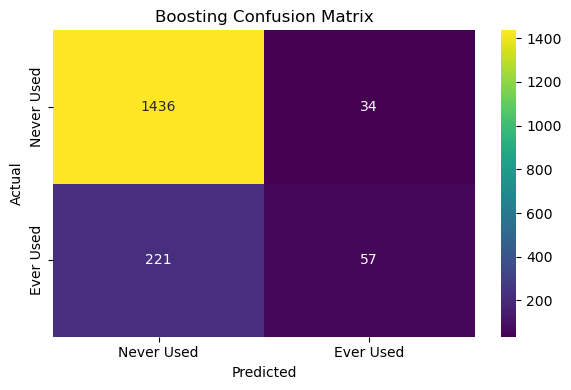

In [69]:
# generate confusion matrix using seaborn
cm_boost = confusion_matrix_sklearn(y_test, y_pred_boost)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_boost, annot=True, fmt='d', xticklabels=['Never Used', 'Ever Used'], yticklabels=['Never Used', 'Ever Used'], cmap='viridis')
plt.title('Boosting Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [40]:
print(classification_report(y_test, y_pred_boost, target_names=['Never Used', 'Ever Used']))

              precision    recall  f1-score   support

  Never Used       0.87      0.98      0.92      1470
   Ever Used       0.63      0.21      0.31       278

    accuracy                           0.85      1748
   macro avg       0.75      0.59      0.61      1748
weighted avg       0.83      0.85      0.82      1748



In [41]:
importances = pd.DataFrame({'feature_name': X.columns, 'importance': df1_boost_final.feature_importances_})
importances = importances.sort_values('importance', ascending=False).reset_index(drop=True)
print(importances)

   feature_name  importance
0      PRMJEVR2    0.458557
1    EDUSCHGRD2    0.195994
2      PRPROUD2    0.059855
3       ARGUPAR    0.048910
4      NEWRACE2    0.042318
5        INCOME    0.034213
6      PRLMTTV2    0.032433
7       COUTYP4    0.031819
8      PARLMTSN    0.023744
9         IRSEX    0.023355
10     PARCHKHW    0.013720
11      RLGATTD    0.013384
12     PARHLPHW    0.012720
13     PRVDRGO2    0.008978


The top features for predicting marijuana usage are again grade level (EDUSCHGRD2), PRMJEVR2 (parental attitudes around youth using marijuana), NEWRACE2 (race/ethnicity), and income (household income level), with PRMJEVR2 exhibiting the greatest importance by a wider margin compared to previous models.

## Multi-Class Classification: How frequently does the respondent use marijuana?

For multi-class classification, a standard decision tree model and random forest model are compared for their ability to accurately predict between three target classes of marijuana usage: having used in the past year, having used but not in the past year, and having not used at all.

In [42]:
# define predictor variables and target variable
X2 = df1[predictors]
y2 = df1['IRMJFY_classes'] # column of numerical values representing 3 different categories

# split the data between test and train
# stratify applied to ensure train and test sets have same class breakdown as original data
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2
                                                    , train_size=0.8
                                                    , random_state=1
                                                    , stratify=y2)

### Applying Decision Tree Model

A Decision Tree Classifer is applied to the multi-class classification training data. Cross-validation is applied to determine the optimal number of terminal nodes for a pruned decision tree model. This pruned model is then applied to the data, plotted, and assessed for its accuracy, error rate, and F1 scores.

In [43]:
# fit decision tree model
mctree_df = DecisionTreeClassifier(random_state=1)

In [44]:
# cross-validation to determine optimal hyperparameters
params_dt_mc = {'max_leaf_nodes': range(2,50),
                'min_samples_split': [2, 5, 10],
                'min_samples_leaf': [1, 2, 5]}

cv_df2 = GridSearchCV(mctree_df, params_dt_mc, cv=10)
cv_df2.fit(X_train2, y_train2)

# find best hyperparameters
print("Best hyperparameters:", cv_df2.best_params_)
print("Best CV score: {:.4f}".format(cv_df2.best_score_))

# define pruned decision tree model using best estimator from cross-validation object
prune_df2 = cv_df2.best_estimator_

Best hyperparameters: {'max_leaf_nodes': 11, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV score: 0.8597


In [45]:
# predict on test data
prune_df2_pred = prune_df2.predict(X_test2)

# create confusion matrix
confusion_matrix_prunedf2 = pd.crosstab(index=prune_df2_pred, columns=y_test2, rownames=[''])
print(confusion_matrix_prunedf2)

# calculate test accuracy and error rate
test_accuracy_prunedf2 = prune_df2.score(X_test2, y_test2)
print("Accuracy: {:.2f}%".format(test_accuracy_prunedf2*100))
print("Error Rate: {:.2f}%".format((1 - test_accuracy_prunedf2)*100))

IRMJFY_classes     0   1    2
                             
0               1461  36  178
2                 28   6   39
Accuracy: 85.81%
Error Rate: 14.19%


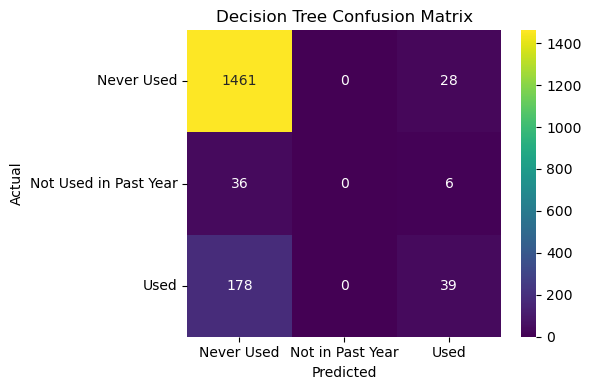

In [70]:
# generate confusion matrix using seaborn
cm_mctree = confusion_matrix_sklearn(y_test2, prune_df2_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_mctree, annot=True, fmt='d', xticklabels=['Never Used', 'Not in Past Year', 'Used'], yticklabels=['Never Used', 'Not Used in Past Year', 'Used'], cmap='viridis')
plt.title('Decision Tree Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [47]:
print(classification_report(y_test2, prune_df2_pred, target_names=['Never Used', 'Not in Past Year', 'Used in Past Year']))

                   precision    recall  f1-score   support

       Never Used       0.87      0.98      0.92      1489
 Not in Past Year       0.00      0.00      0.00        42
Used in Past Year       0.53      0.18      0.27       217

         accuracy                           0.86      1748
        macro avg       0.47      0.39      0.40      1748
     weighted avg       0.81      0.86      0.82      1748



C:\Users\jacob\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\jacob\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\jacob\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


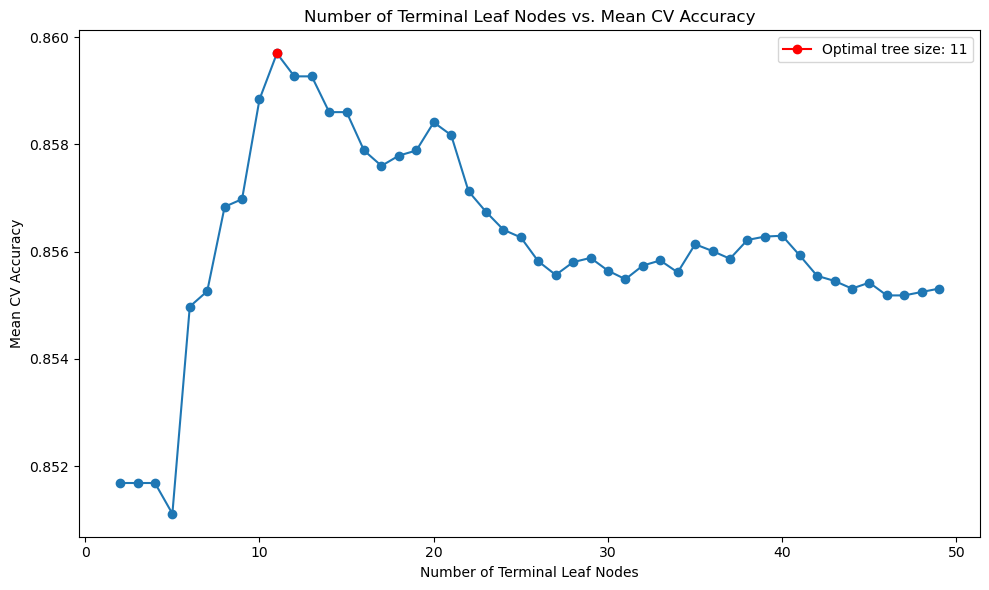

In [48]:
# define best_size and best CV score variables
best_size2 = cv_df2.best_params_['max_leaf_nodes']
best_score2 = cv_df2.best_score_

# plot number of terminal leaf nodes vs mean CV score for all combinations of hyperparameters
cv_results_df2 = pd.DataFrame(cv_df2.cv_results_)
leaf_node_scores = cv_results_df2.groupby('param_max_leaf_nodes')['mean_test_score'].mean()

plt.figure(figsize=(10, 6))
plt.plot(leaf_node_scores.index, leaf_node_scores.values, 'o-')
plt.plot(best_size2, best_score2, 'ro-', label=f'Optimal tree size: {best_size2}')
plt.xlabel('Number of Terminal Leaf Nodes')
plt.ylabel('Mean CV Accuracy')
plt.title('Number of Terminal Leaf Nodes vs. Mean CV Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

In [49]:
importances = pd.DataFrame({'feature_name': X2.columns, 'importance': prune_df2.feature_importances_})
importances = importances.sort_values('importance', ascending=False).reset_index(drop=True)
print(importances)

   feature_name  importance
0      PRMJEVR2    0.668774
1    EDUSCHGRD2    0.210870
2       ARGUPAR    0.055392
3      PRPROUD2    0.048322
4      NEWRACE2    0.016643
5         IRSEX    0.000000
6        INCOME    0.000000
7       COUTYP4    0.000000
8       RLGATTD    0.000000
9      PRVDRGO2    0.000000
10     PARCHKHW    0.000000
11     PARHLPHW    0.000000
12     PRLMTTV2    0.000000
13     PARLMTSN    0.000000


For the multi-class classification decision tree model, the PRMJEVR2 variable again appears to dominate the features by a wide margin similar to the binary classification model. This model also appeared to struggle with the class 'Not in Past Year', failing to correctly predict any of the values in this class. This failure in predictive accuracy could be due to significant class imbalance.

### Applying Random Forest Model

A Random Forest Classifer is applied to the multi-class classification training data using half of the available predictors and inspected for its training score. This model is then used to generate predictions on the test data and examined for its accuracy and error rate. The features are also ranked in terms of their importance scores.

In [50]:
# fit Random Forests model
df1_rfmc = RandomForestClassifier(random_state = 1)

In [51]:
# cross-validation to determine optimal hyperparameters
params_rfmc = {'n_estimators': [100, 300, 500],
              'max_features': ['sqrt', 0.5], 
              'max_depth': [3, 5, 10, None],
              'min_samples_split': [2, 5, 10],
              'min_samples_leaf': [1, 2, 5]}

cv_rfmc = GridSearchCV(df1_rfmc, params_rfmc, cv=5, n_jobs=-1)
cv_rfmc.fit(X_train2, y_train2)

# find best hyperparameters
print("Best hyperparameters:", cv_rfmc.best_params_)
print("Best CV score: {:.4f}".format(cv_rfmc.best_score_))

# define random forest model using best estimator from cross-validation object
df1_rfmc_final = cv_rfmc.best_estimator_ 

Best hyperparameters: {'max_depth': 5, 'max_features': 0.5, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 500}
Best CV score: 0.8588


In [52]:
# Predict values
y_pred_rfmc = df1_rfmc_final.predict(X_test2)

# create confusion matrix
confusion_matrix_rfmc = pd.crosstab(index=y_pred_rfmc, columns=y_test2, rownames=[''])
print(confusion_matrix_rfmc)

# calculate test accuracy and error rate
test_accuracy_rfmc = df1_rfmc_final.score(X_test2, y_test2)
print("Accuracy: {:.2f}%".format(test_accuracy_rfmc*100))
print("Error Rate: {:.2f}%".format((1 - test_accuracy_rfmc)*100))

IRMJFY_classes     0   1    2
                             
0               1472  37  189
2                 17   5   28
Accuracy: 85.81%
Error Rate: 14.19%


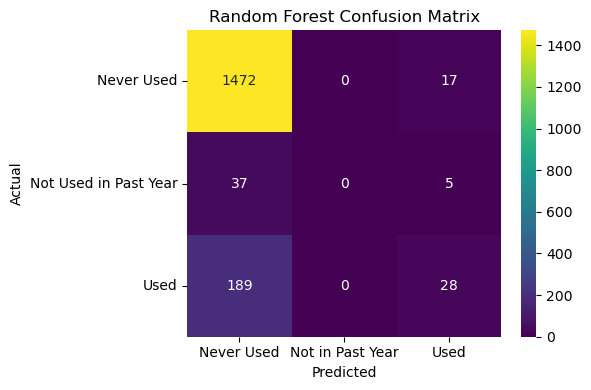

In [71]:
# generate confusion matrix using seaborn
cm_rfmc = confusion_matrix_sklearn(y_test2, y_pred_rfmc)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_rfmc, annot=True, fmt='d', xticklabels=['Never Used', 'Not in Past Year', 'Used'], yticklabels=['Never Used', 'Not Used in Past Year', 'Used'], cmap='viridis')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [54]:
print(classification_report(y_test2, y_pred_rfmc, target_names=['Never Used', 'Not in Past Year', 'Used in Past Year']))

                   precision    recall  f1-score   support

       Never Used       0.87      0.99      0.92      1489
 Not in Past Year       0.00      0.00      0.00        42
Used in Past Year       0.56      0.13      0.21       217

         accuracy                           0.86      1748
        macro avg       0.48      0.37      0.38      1748
     weighted avg       0.81      0.86      0.81      1748



C:\Users\jacob\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\jacob\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\jacob\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [55]:
importances = pd.DataFrame({'feature_name': X2.columns, 'importance': df1_rfmc_final.feature_importances_})
importances = importances.sort_values('importance', ascending=False).reset_index(drop=True)
print(importances)

   feature_name  importance
0      PRMJEVR2    0.530331
1    EDUSCHGRD2    0.208173
2      PRPROUD2    0.052569
3       ARGUPAR    0.045464
4      PRLMTTV2    0.037305
5      PARHLPHW    0.028843
6      NEWRACE2    0.023717
7        INCOME    0.017260
8      PARCHKHW    0.013672
9       COUTYP4    0.010717
10     PARLMTSN    0.010401
11        IRSEX    0.009678
12      RLGATTD    0.009045
13     PRVDRGO2    0.002825


For this random forest model, the top features for predicting marijuana usage are grade level (EDUSCHGRD2) and  parental attitudes around youth using marijuana (PRMJEVR2). The model's accuracy was equal to that of the pruned decision tree model, though it correctly identified less individuals who had used in the past year, who belong to a minority class.

## Regression: How old was the respondent when they first used marijuana?

For regression, a standard decision tree model and gradient boosting model are compared for their accuracy in predicting the age at which a respondent first used marijuana based on the chosen predictor variables.

In [56]:
# define predictor variables and target variable
X3 = df3[predictors]
y3 = df3['IRMJAGE']

# split the data between test and train
X_train3, X_test3, y_train3, y_test3 = train_test_split(X3, y3
                                                    , train_size=0.8
                                                    , random_state=1)

### Applying Decision Tree Model

A Decision Tree Regressor is applied by first using cross-validation to determine the optimal hyperparameters and being used to generate predictions on the test data. The optimal model's accuracy is then assessed using the metrics of mean squared error, root mean squared error, and coefficient of determination. A feature importance table is also output for this model.

In [57]:
# fit decision tree regressor
tree_df3 = DecisionTreeRegressor(random_state=1)

In [58]:
# cross-validation to determine optimal hyperparameters
params_dtr = {'max_leaf_nodes': range(2,50),
          'min_samples_split': [2, 5, 10],
          'min_samples_leaf': [1, 2, 5]}

cv_dtr = GridSearchCV(tree_df3, params_dtr, cv=10)
cv_dtr.fit(X_train3, y_train3)

# find best hyperparameters
print("Best hyperparameters:", cv_dtr.best_params_)
print("Best CV score (R-squared): {:.4f}".format(cv_dtr.best_score_))

# define pruned decision tree model model using best estimator from cross-validation object
tree_df3_final = cv_dtr.best_estimator_

Best hyperparameters: {'max_leaf_nodes': 11, 'min_samples_leaf': 5, 'min_samples_split': 2}
Best CV score (R-squared): 0.2194


In [59]:
y_pred3 = tree_df3_final.predict(X_test3)
MSE = mean_squared_error(y_test3, y_pred3)
RMSE = np.sqrt(mean_squared_error(y_test3, y_pred3))
r2 = r2_score(y_test3, y_pred3)

print("Test MSE: {:.4f}".format(MSE))
print("Test RMSE: {:.4f}".format(RMSE))
print("Test R²: {:.4f}".format(r2))

Test MSE: 2.5586
Test RMSE: 1.5996
Test R²: 0.1173


In [60]:
np.std(df3['IRMJAGE'])

1.7440675022838146

In [61]:
importances = pd.DataFrame({'feature_name': X3.columns, 'importance': tree_df3_final.feature_importances_})
importances = importances.sort_values('importance', ascending=False).reset_index(drop=True)
print(importances)

   feature_name  importance
0    EDUSCHGRD2    0.814234
1      PRMJEVR2    0.069213
2       COUTYP4    0.058264
3        INCOME    0.031732
4      PARCHKHW    0.026557
5         IRSEX    0.000000
6      NEWRACE2    0.000000
7       RLGATTD    0.000000
8      PRVDRGO2    0.000000
9       ARGUPAR    0.000000
10     PARHLPHW    0.000000
11     PRLMTTV2    0.000000
12     PARLMTSN    0.000000
13     PRPROUD2    0.000000


The final decision tree model results in a root mean squared error value that falls below the standard deviation of the target variable IRMJAGE (age of first use of marijuana), suggesting that this model is slightly more predictive than predicting based on the mean value of the data. Additionally, grade level appears to significantly outclass all other features in terms of magnitude of importance.

### Applying Boosting Model

A Gradient Boosting Regressor is then applied by first using cross-validation to determine the optimal hyperparameters before generating predictions on the test data. The optimal model's accuracy is then assessed using the metrics of mean squared error, root mean squared error, and coefficient of determination. A feature importance table is also output for this model.

In [62]:
boost_df3 = GradientBoostingRegressor(random_state = 1)

In [63]:
# cross-validation to determine optimal hyperparameters
params_boost_r = {'n_estimators': [100, 300, 500],
                'learning_rate': [0.001, 0.01, 0.1],
                'max_depth': [3, 5, 10, None],
                'min_samples_split': [2, 5, 10],
                'min_samples_leaf': [1, 2, 5]}

cv_boost_r = RandomizedSearchCV(boost_df3, params_boost_r, n_iter=20, cv=5, n_jobs=-1, random_state=1)
cv_boost_r.fit(X_train3, y_train3)

# find best hyperparameters
print("Best hyperparameters:", cv_boost_r.best_params_)
print("Best CV score (R-squared): {:.4f}".format(cv_boost_r.best_score_))

# define boosting model using best estimator from cross-validation object
boost_df3_final = cv_boost_r.best_estimator_ 

Best hyperparameters: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 5, 'learning_rate': 0.01}
Best CV score (R-squared): 0.1993


In [64]:
y_pred_boost_df3 = boost_df3_final.predict(X_test3)
MSE = mean_squared_error(y_test3, y_pred_boost_df3)
RMSE = np.sqrt(mean_squared_error(y_test3, y_pred_boost_df3))
r2 = r2_score(y_test3, y_pred_boost_df3)

print("Test MSE: {:.4f}".format(MSE))
print("Test RMSE: {:.4f}".format(RMSE))
print("Test R²: {:.4f}".format(r2))

Test MSE: 2.4854
Test RMSE: 1.5765
Test R²: 0.1425


In [65]:
importances = pd.DataFrame({'feature_name': X3.columns, 'importance': boost_df3_final.feature_importances_})
importances = importances.sort_values('importance', ascending=False).reset_index(drop=True)
print(importances)

   feature_name  importance
0    EDUSCHGRD2    0.528574
1       COUTYP4    0.081930
2        INCOME    0.072122
3      NEWRACE2    0.071223
4      PRMJEVR2    0.048364
5         IRSEX    0.033098
6       ARGUPAR    0.032341
7      PARCHKHW    0.028665
8      PARLMTSN    0.027232
9      PRPROUD2    0.025352
10      RLGATTD    0.018760
11     PARHLPHW    0.014642
12     PRVDRGO2    0.011350
13     PRLMTTV2    0.006348


With the optimal shrinkage parameter of 0.01, the boosting model slightly outperformed the decision tree model in terms of predictive accuracy. Grade level again appeared to be the most important feature/predictor.

## Final Model Comparisons
| Binary Classification Model | Accuracy | Error Rate | Never Used F1 Score | Ever Used F1 Score |
|---|---|---|---|---|
| Decision Tree | 84.73% | 15.27% | 0.92 | 0.24 | 
| Bagging | 84.90% | 15.10% | 0.92  | 0.24 | 
| Random Forest | 85.24% | 14.76% | 0.92 | 0.29 | 
| Boosting | 85.41% | 14.59% | 0.92 | 0.31 |

| Multi-class Classification Model | Accuracy | Error Rate | Never Used F1 Score | Ever Used F1 Score |
|---|---|---|---|---|
| Decision Tree | 85.81% | 14.19% | 0.92 | 0.27 | 
| Random Forest | 85.81% | 14.19% | 0.92 | 0.21 | 


| Regression Model | MSE | RMSE | R² |
|---|---|---|---|
| Decision Tree | 2.5586 | 1.5996 | 0.1173 |
| Boosting | 2.4854 | 1.5765 | 0.1425 |

For binary classification, boosting achieved the highest accuracy rate as well as the highest F1 score when predicting for the minority class. Between the two multi-class classification models, they achieved the same accuracy rate though the decision tree model had the higher F1 score for the minority class of "Ever Used". Both models failed to predict any of of the "Not in Past Year" class. With respect to regression, boosting achieved a slightly better accuracy compared to the decision tree model.